# Task 03 – End-to-End Machine Learning Project

## Credit Card Fraud Detection

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.shape)

(284807, 31)


In [5]:
## 3. Understand the Dataset
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 284807
Number of Columns: 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  flo

In [6]:
print("First 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nStatistical Summary:")
display(df.describe())

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Last 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0



Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
print("First 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nStatistical Summary:")
display(df.describe())

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Last 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0



Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
###  Missing Values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
### Duplicate Records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1081


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of transactions, identify patterns, and analyze the relationship between features and fraudulent transactions.

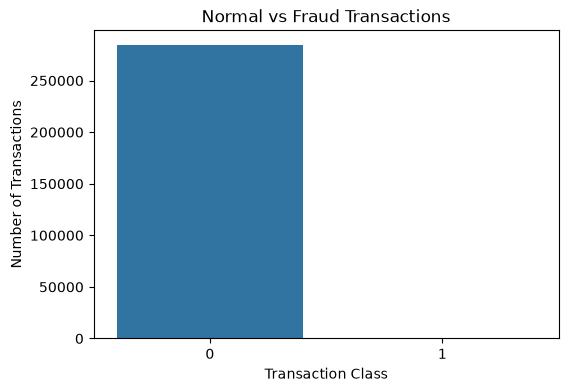

In [10]:
### Transaction Class Distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='Class', data=df)

plt.title('Normal vs Fraud Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')

plt.show()

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


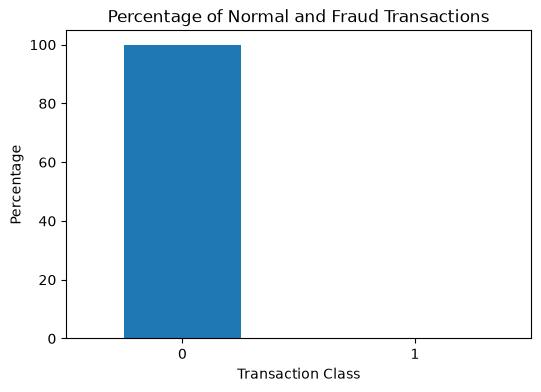

In [11]:
###  Transaction Class Percentage
class_percentage = df['Class'].value_counts(normalize=True) * 100

print(class_percentage)

plt.figure(figsize=(6, 4))

class_percentage.plot(kind='bar')

plt.title('Percentage of Normal and Fraud Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Percentage')

plt.xticks(rotation=0)
plt.show()

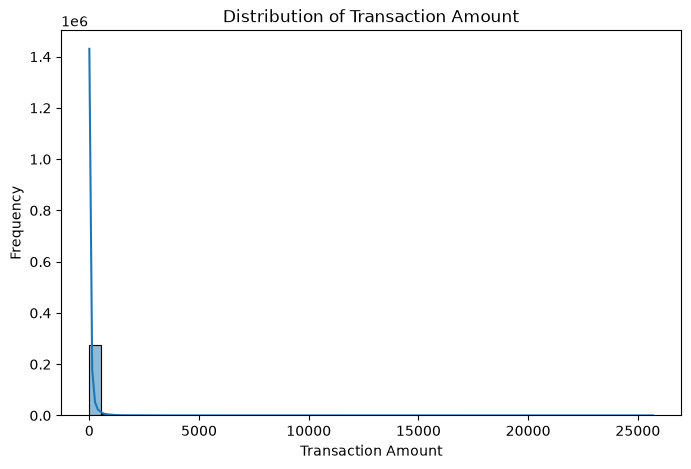

In [12]:
###  Transaction Amount Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

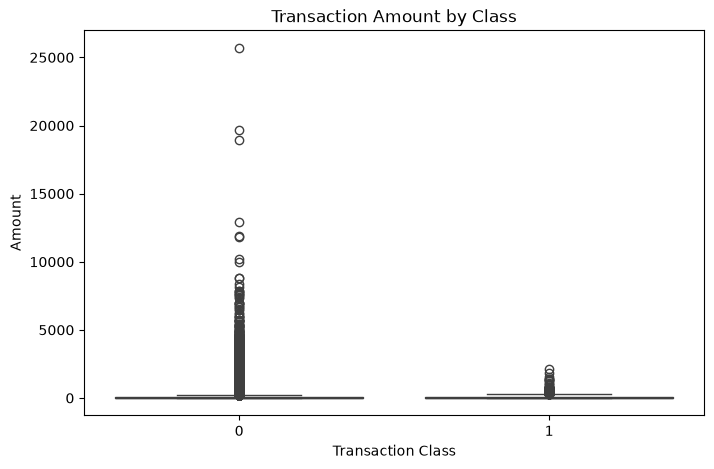

In [13]:
### Transaction Amount by Class
plt.figure(figsize=(8, 5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')
plt.xlabel('Transaction Class')
plt.ylabel('Amount')

plt.show()

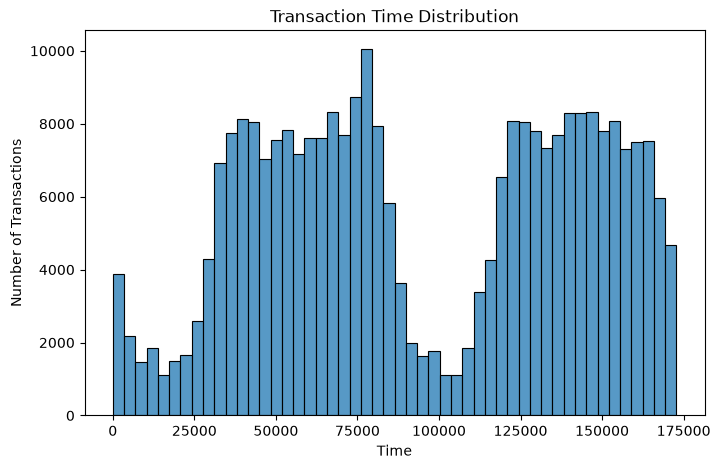

In [14]:
### Transaction Time Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df['Time'], bins=50)

plt.title('Transaction Time Distribution')
plt.xlabel('Time')
plt.ylabel('Number of Transactions')

plt.show()

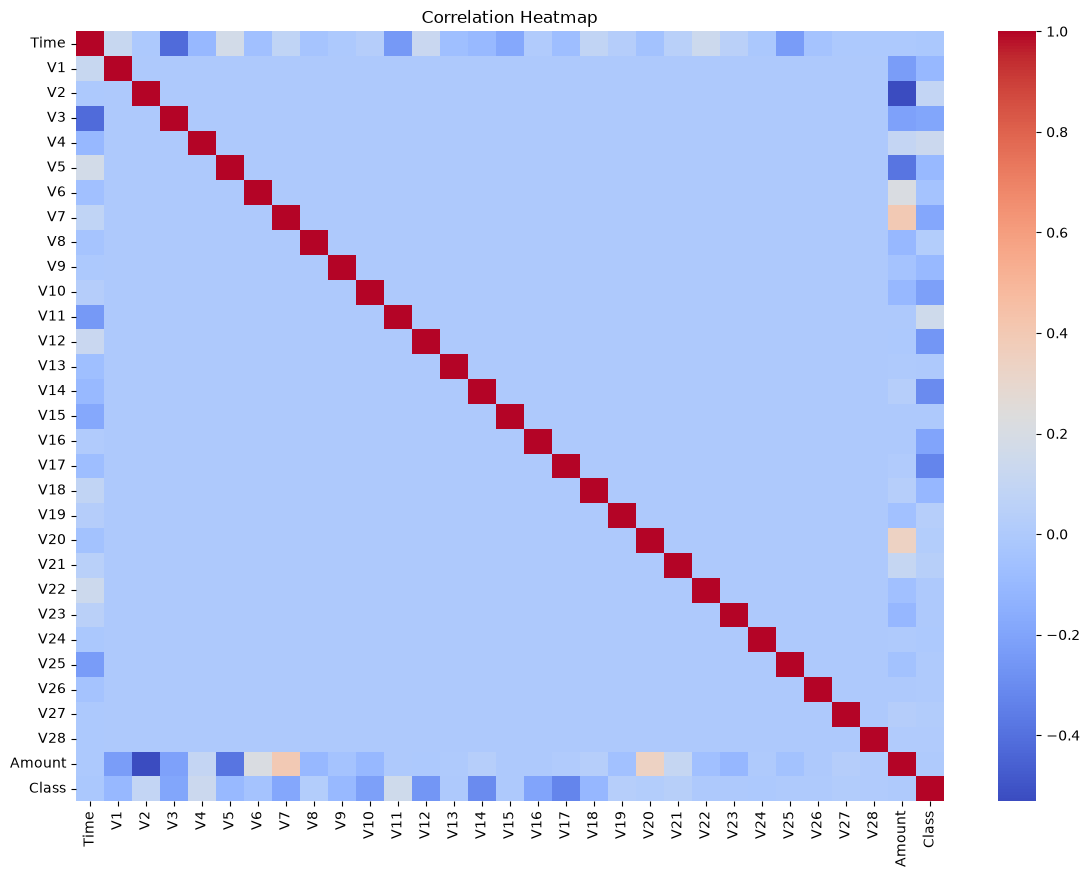

In [15]:
### Feature Correlation Heatmap
plt.figure(figsize=(14, 10))

correlation = df.corr()

sns.heatmap(correlation, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

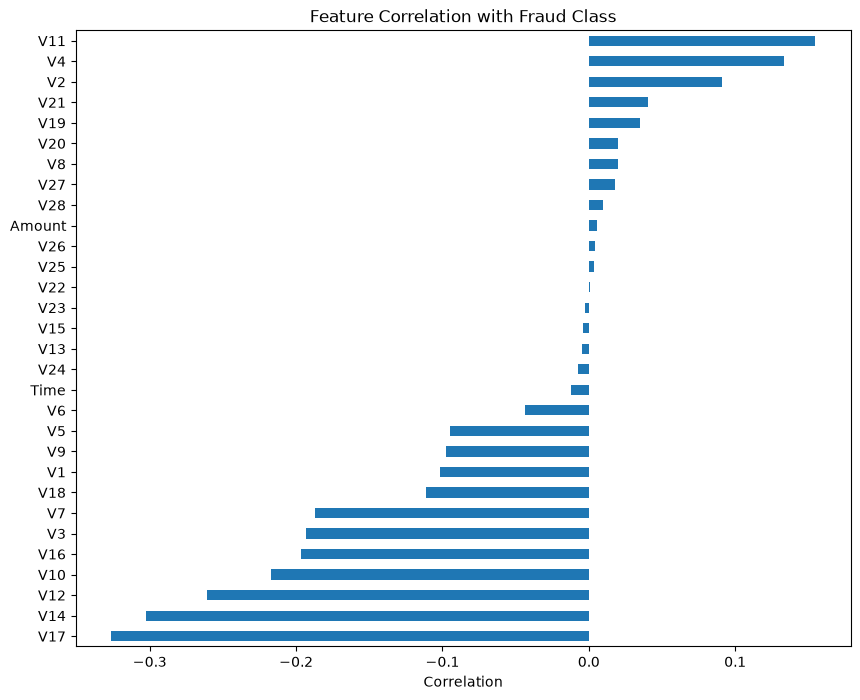

In [16]:
###  Feature Correlation with Fraud Class
class_corr = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))

class_corr.plot(kind='barh')

plt.title('Feature Correlation with Fraud Class')
plt.xlabel('Correlation')

plt.show()

## 6: Feature Engineering

In [17]:
# Create a new feature using transaction amount
df['Amount_Log'] = np.log1p(df['Amount'])

# Display the new feature
df[['Amount', 'Amount_Log']].head()

,Amount,Amount_Log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [18]:
print("Dataset shape after feature engineering:", df.shape)

Dataset shape after feature engineering: (284807, 32)


## 7. Feature Selection

In [19]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 31)
Target shape: (284807,)


In [20]:
print("Target column:", y.name)
print("Number of features:", X.shape[1])

Target column: Class
Number of features: 31


## 8. Data Scaling

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 31)
Testing data: (56962, 31)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (227845, 31)
Scaled testing data shape: (56962, 31)


## 9. Model Development

In [23]:
# Define ML models

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

decision_tree_model = DecisionTreeClassifier(random_state=42)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingClassifier(random_state=42)

In [24]:
# Train the models

logistic_model.fit(X_train_scaled, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

gradient_boosting_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


## 10. Model Evaluation

In [25]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [26]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [27]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [28]:
gradient_boosting_model = GradientBoostingClassifier(random_state=42)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [29]:
# Make predictions

y_pred_lr = logistic_model.predict(X_test_scaled)

y_pred_dt = decision_tree_model.predict(X_test)

y_pred_rf = random_forest_model.predict(X_test)

y_pred_gb = gradient_boosting_model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [30]:
# Model Performance
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for name, predictions in models.items():
    print("\n", name)
    print("Accuracy :", accuracy_score(y_test, predictions))
    print("Precision:", precision_score(y_test, predictions, zero_division=0))
    print("Recall   :", recall_score(y_test, predictions, zero_division=0))
    print("F1 Score :", f1_score(y_test, predictions, zero_division=0))


 Logistic Regression
Accuracy : 0.9991748885221726
Precision: 0.8311688311688312
Recall   : 0.6530612244897959
F1 Score : 0.7314285714285714

 Decision Tree
Accuracy : 0.9991573329588147
Precision: 0.7604166666666666
Recall   : 0.7448979591836735
F1 Score : 0.7525773195876289

 Random Forest
Accuracy : 0.9996137776061234
Precision: 0.9523809523809523
Recall   : 0.8163265306122449
F1 Score : 0.8791208791208791

 Gradient Boosting
Accuracy : 0.9983146659176293
Precision: 0.5294117647058824
Recall   : 0.1836734693877551
F1 Score : 0.2727272727272727


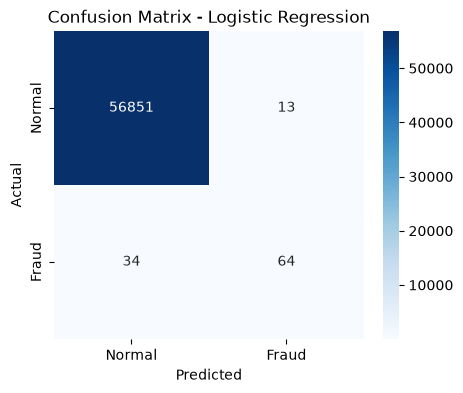

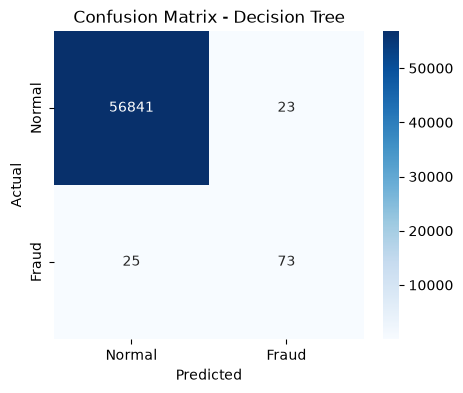

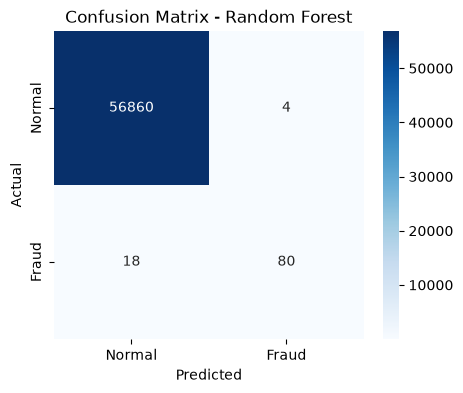

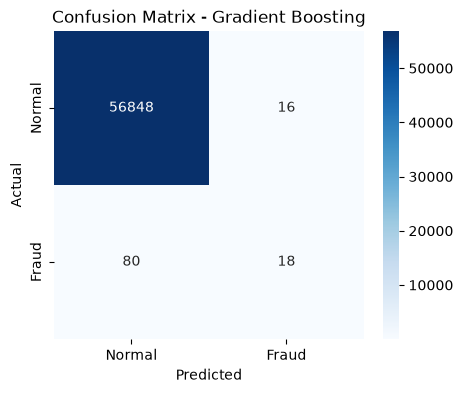

In [31]:
### 10.3 Confusion Matrix
# Confusion Matrix for all models

for name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 11 — Hyperparameter Tuning

In [32]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_test = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf_test.fit(X_train, y_train)

y_pred = rf_test.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.9995611109160493


In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [20, 30],
    'max_depth': [10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ),
    param_grid=param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Parameters: {'max_depth': 10, 'n_estimators': 30}
Best CV Score: 0.9994601594151391


## 12 — Cross Validation

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Best parameters from Step 11
best_rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

# 5-Fold Cross Validation
cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.99947333 0.99951722 0.99942944 0.99953916 0.99949527]

Mean CV Accuracy:
0.9994908819592266

Standard Deviation:
3.7755163672876034e-05


 ## 13  Feature Importance Analysis

In [38]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Best Random Forest
best_rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

# Train model
best_rf.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [39]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

       Feature  Importance
17         V17    0.172613
14         V14    0.156868
10         V10    0.150153
12         V12    0.108012
11         V11    0.077812
16         V16    0.040197
4           V4    0.039000
18         V18    0.030848
9           V9    0.025172
26         V26    0.019267
7           V7    0.017107
20         V20    0.014190
2           V2    0.012596
21         V21    0.011626
28         V28    0.010897
1           V1    0.009697
8           V8    0.009099
3           V3    0.008832
19         V19    0.008771
27         V27    0.008260
6           V6    0.007783
15         V15    0.007576
29      Amount    0.007474
5           V5    0.007416
0         Time    0.007091
13         V13    0.006036
23         V23    0.005911
30  Amount_Log    0.005289
25         V25    0.005037
22         V22    0.004711
24         V24    0.004658


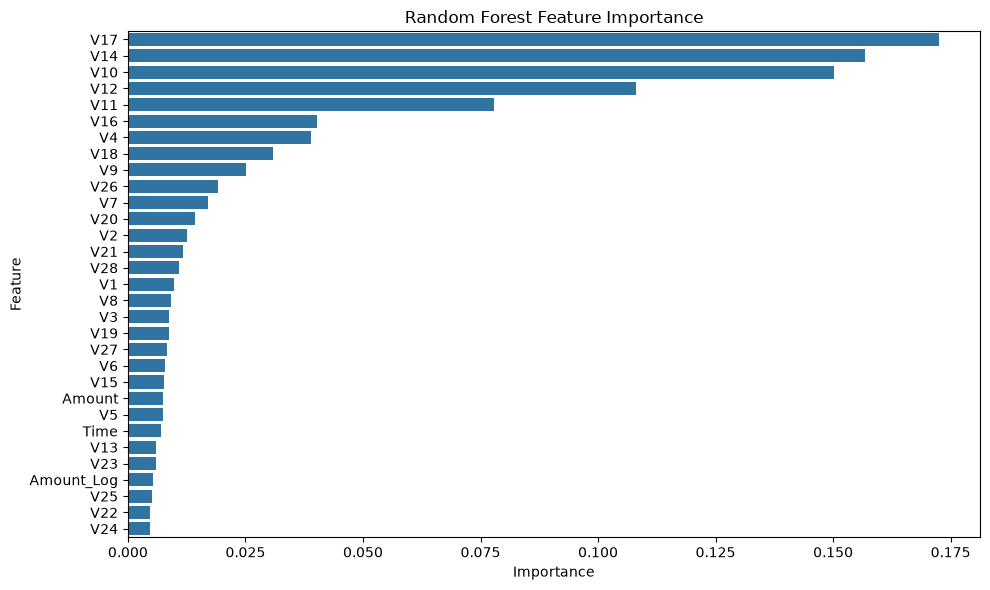

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

 ## 14 — Best Model Save

In [41]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Best model
best_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

# Train the best model
best_model.fit(X_train, y_train)

print("Best model trained successfully!")

Best model trained successfully!


In [42]:
# Save model
joblib.dump(best_model, "best_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [43]:
import joblib

loaded_model = joblib.load("best_model.pkl")

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
RandomForestClassifier(max_depth=10, n_estimators=30, n_jobs=1, random_state=42)


# Step 15 — Project Documentation

In [ ]:


## 1. Project Objective

The objective of this project is to build and compare machine learning models
using a real-world dataset. The project includes data preprocessing,
exploratory data analysis, model training, hyperparameter tuning,
cross-validation, feature importance analysis, and final model saving.

## 2. Dataset Description

The dataset was used to train machine learning models for prediction.
The data was cleaned and prepared before applying machine learning algorithms.

## 3. Data Preprocessing

The following preprocessing steps were performed:

- Loaded the dataset using Pandas.
- Checked missing values.
- Checked and removed duplicate records where required.
- Encoded categorical variables.
- Scaled numerical features where required.
- Divided the data into training and testing sets.

## 4. Machine Learning Models

Different machine learning algorithms were evaluated during the project.

The models included:

- Linear Regression
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

## 5. Hyperparameter Tuning

Hyperparameter tuning was performed on the Random Forest model using
GridSearchCV.

The best parameters obtained were:

- n_estimators = 30
- max_depth = 10

Best Cross-Validation Score:

0.999460

## 6. Cross Validation

Five-fold cross-validation was performed to evaluate the stability
of the tuned Random Forest model.

Mean Cross-Validation Accuracy:

0.999491

Standard Deviation:

0.0000378

## 7. Feature Importance Analysis

Feature importance was analyzed using the Random Forest model.
This analysis helps identify which features contributed most to
the model's predictions.

## 8. Best Model

The selected model was Random Forest with the following parameters:

- n_estimators = 30
- max_depth = 10
- random_state = 42

## 9. Model Saving

The final trained model was saved using Joblib.

File name:

best_model.pkl

The saved model was successfully loaded again and verified.

## 10. Conclusion

In this project, the dataset was preprocessed and machine learning
models were developed and evaluated. Hyperparameter tuning and
cross-validation were performed to evaluate the Random Forest model.
Feature importance analysis was also conducted, and the final trained
model was successfully saved using Joblib for future predictions.